In [1]:
import pandas as pd
import numpy as np
import os
from paths import Paths

feat = ['L.PU-L.CACG',
'L.PU-L.RACG',
'R.PU-R.CACG',
'R.PU-R.RACG',
'L.PU-L.IN',
'R.PU-R.IN',
'L.CA-L.HI',
'R.CA-R.HI',
'VAR_FCD']

In [ ]:
pid = 'sub-2015060401'
med_results = pd.read_csv(f'{Paths.RESULTS}/{pid}/{Paths.TYPE_OF_SWEEP}_medication_extracted_features.csv', index_col = 0)

score_dfs = []

for medication in np.unique(med_results['medication']):
    med_results_specific_med = med_results[med_results['medication']==medication]
    med_results_specific_med = med_results_specific_med.sort_values(['med_zi'])
    med_results_specific_med.reset_index(inplace=True)
    base_med_zi = med_results_specific_med['med_zi'].min()
    base_feat = med_results_specific_med[med_results_specific_med['med_zi']==base_med_zi][feat]
    score_i = []
    med_zi_i = []

    for i in med_results_specific_med.index:
        for j in base_feat.index:
            score_i.append(np.sum(med_results_specific_med.loc[i, feat] - base_feat.loc[j, feat]))
            med_zi_i.append(med_results_specific_med.loc[i, 'med_zi'])

    score_df = pd.DataFrame({'score': score_i, 'medication': [medication]*len(score_i), 'med_zi': med_zi_i})
    score_dfs.append(score_df)

result_df = pd.concat(score_dfs, axis=0)
#result_df.to_csv(f'{med_results_dir}/{Paths.TYPE_OF_SWEEP}_medication_diff.csv')

NameError: name 'med_results_dir' is not defined

In [5]:
result_df

,score,medication,med_zi,med_zi_norm
0,0.000000,amisulpride,40,0
1,-0.167510,amisulpride,40,0
2,-0.130406,amisulpride,40,0
3,-0.294680,amisulpride,40,0
4,-0.175021,amisulpride,40,0
...,...,...,...,...
49995,0.067854,olanzapine,79,19
49996,0.114905,olanzapine,79,19
49997,0.512503,olanzapine,79,19
49998,0.549122,olanzapine,79,19


In [6]:
med_color_dict

{'amisulpride': (np.float64(0.267004),
  np.float64(0.004874),
  np.float64(0.329415),
  np.float64(1.0)),
 'aripiprazole': (np.float64(0.190631),
  np.float64(0.407061),
  np.float64(0.556089),
  np.float64(1.0)),
 'clozapine': (np.float64(0.20803),
  np.float64(0.718701),
  np.float64(0.472873),
  np.float64(1.0)),
 'olanzapine': (np.float64(0.993248),
  np.float64(0.906157),
  np.float64(0.143936),
  np.float64(1.0))}

In [8]:
med_color_dict[med]

(np.float64(0.993248),
 np.float64(0.906157),
 np.float64(0.143936),
 np.float64(1.0))

/var/folders/65/0rggzw_s3c39y4m504krlw380000gn/T/ipykernel_54723/4274373668.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")  # continuous colormap


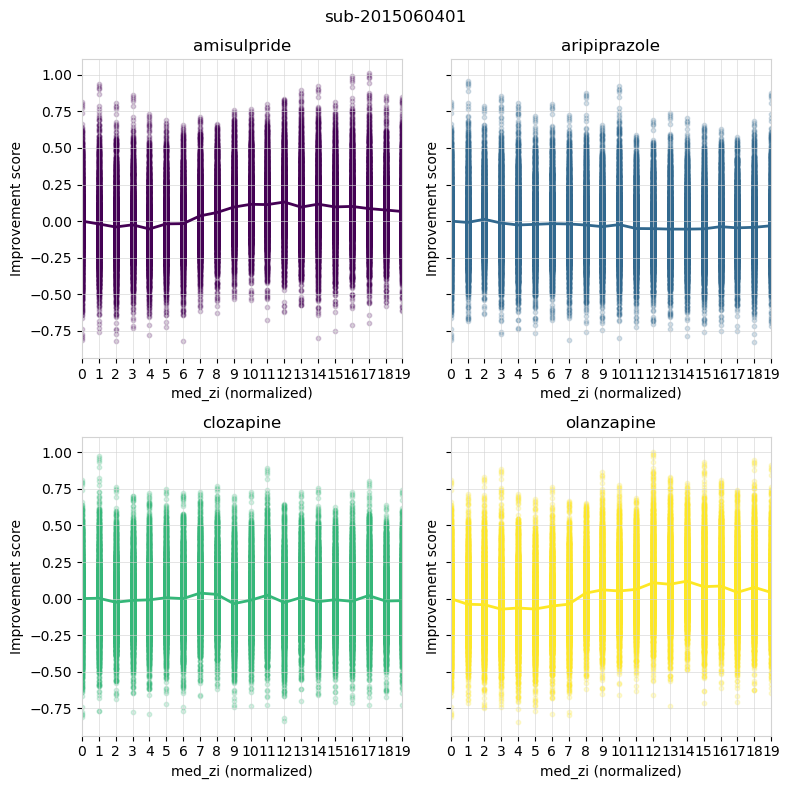

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- Create consistent color mapping for medications ---
med_types = result_df['medication'].unique()
viridis = cm.get_cmap("viridis")  # continuous colormap
med_color_dict = {med: viridis(i / (len(med_types) - 1)) for i, med in enumerate(med_types)}

# --- Normalize med_zi ---
result_df['med_zi_norm'] = result_df.groupby('medication')['med_zi'].transform(lambda x: x - x.min())

# --- Create subplots ---
n_cols = 2
n_rows = int(np.ceil(len(med_types)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), sharey=True)
axes = axes.flatten()

for i, med in enumerate(med_types):
    ax = axes[i]
    med_df_plot = result_df[result_df['medication'] == med]
    color = med_color_dict[med]

    # Scatter points
    ax.scatter(
        med_df_plot['med_zi_norm'],
        med_df_plot['score'],
        alpha=0.2,
        s=10,
        color=color,
        label=med
    )

    # Mean line
    med_zi_unique = np.sort(med_df_plot['med_zi_norm'].unique())
    mean_score = med_df_plot.groupby('med_zi_norm')['score'].mean()
    ax.plot(
        mean_score.index,
        mean_score.values,
        color=color,
        linewidth=2
    )

    ax.set_title(med)
    ax.set_xlim(0, 19)
    ax.set_xticks(range(20))
    ax.set_xlabel("med_zi (normalized)")
    ax.set_ylabel("Improvement score")
    ax.grid(True, color="lightgray", linewidth=0.6, alpha=0.7)

    for spline in ax.spines.values():
        spline.set_color('lightgray')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle(pid)
plt.tight_layout()
plt.show()